In [1]:
# ============================================
# 1. IMPORTS
# ============================================
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.interpolate import griddata
from scipy.ndimage import sobel, gaussian_filter

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [18]:
# @title
import os, shutil

dst_folder = "/content/"
src_folder = "/content/drive/MyDrive/colab-data/Ranawana"


files = [
    'Site_DEM_points.csv',
    'Ranawana_Clean_Poly.dxf',
    'Ranawana_Drainage_1_110_107.csv',
    'Ranawana_Drainage_2_110_106.csv',
    'Ranawana_Drainage_3_106_105.csv',
    'Ranawana_toe_alignment.csv',
    'Ranawana_slope_cut_fill_3drains.pdf',
    'Ranawana_cut_fill_summary_3drains.csv',
    'Ranawana_3D_Drain_Gabion_CutFill.html',
    'Ranawana_Interactive_Terrain.html',
    'Ranawana_slope_terrain.html',
    'Ranawana_Contour_Map.pdf',
    'Ranawana_3D.html',
    'Ranawana_slopemap.pdf',
    'Ranawana_Field_Ready_Outputs.zip'
]

for file in files:
    src_path = os.path.join(src_folder, file)
    dst_path = os.path.join(dst_folder, file)
    #print(src_path, dst_path)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)   # overwrites automatically
        print(f"Downloaded (overwritten if exists): {file}")
    else:
        print(f"Missing in Drive: {file}")


Missing in Drive: Site_DEM_points.csv
Missing in Drive: Ranawana_Clean_Poly.dxf
Missing in Drive: Ranawana_Drainage_1_110_107.csv
Missing in Drive: Ranawana_Drainage_2_110_106.csv
Missing in Drive: Ranawana_Drainage_3_106_105.csv
Missing in Drive: Ranawana_toe_alignment.csv
Missing in Drive: Ranawana_slope_cut_fill_3drains.pdf
Missing in Drive: Ranawana_cut_fill_summary_3drains.csv
Missing in Drive: Ranawana_3D_Drain_Gabion_CutFill.html
Missing in Drive: Ranawana_Interactive_Terrain.html
Missing in Drive: Ranawana_slope_terrain.html
Missing in Drive: Ranawana_Contour_Map.pdf
Missing in Drive: Ranawana_3D.html
Missing in Drive: Ranawana_slopemap.pdf
Missing in Drive: Ranawana_Field_Ready_Outputs.zip


In [19]:
# @title
import os
import shutil


src_folder = "/content/"
dst_folder = "/content/drive/MyDrive/colab-data/Ranawana"

os.makedirs(dst_folder, exist_ok=True)

for file in files:
    src_path = os.path.join(src_folder, file)
    dst_path = os.path.join(dst_folder, file)
    #print(src_path, dst_path)
    if os.path.exists(src_path):
        shutil.copy2(src_path, dst_path)
        print(f"Copied to Drive: {file}")
    else:
        print(f"Missing: {file}")

Copied to Drive: Site_DEM_points.csv
Copied to Drive: Ranawana_Clean_Poly.dxf
Copied to Drive: Ranawana_Drainage_1_110_107.csv
Copied to Drive: Ranawana_Drainage_2_110_106.csv
Copied to Drive: Ranawana_Drainage_3_106_105.csv
Copied to Drive: Ranawana_toe_alignment.csv
Copied to Drive: Ranawana_slope_cut_fill_3drains.pdf
Copied to Drive: Ranawana_cut_fill_summary_3drains.csv
Copied to Drive: Ranawana_3D_Drain_Gabion_CutFill.html
Copied to Drive: Ranawana_Interactive_Terrain.html
Copied to Drive: Ranawana_slope_terrain.html
Copied to Drive: Ranawana_Contour_Map.pdf
Copied to Drive: Ranawana_3D.html
Copied to Drive: Ranawana_slopemap.pdf
Copied to Drive: Ranawana_Field_Ready_Outputs.zip


Load Clean DEM

In [4]:
# @title
# ============================================
# 2. LOAD DEM
# ============================================

def load_clean_dem(file_path):
    ext = os.path.splitext(file_path)[1].lower()

    if ext == ".csv":
        df = pd.read_csv(file_path)
        cols = [c.lower() for c in df.columns]

        # try to detect x,y,z columns
        x_col = df.columns[cols.index("x")] if "x" in cols else df.columns[0]
        y_col = df.columns[cols.index("y")] if "y" in cols else df.columns[1]
        z_col = df.columns[cols.index("z")] if "z" in cols else df.columns[2]

        xp = df[x_col].values
        yp = df[y_col].values
        zp = df[z_col].values

        return {"type": "points", "xp": xp, "yp": yp, "zp": zp}

    elif ext == ".npz":
        data = np.load(file_path)

        keys = list(data.keys())
        print("NPZ keys:", keys)

        if all(k in keys for k in ["Xi", "Yi", "Zi"]):
            return {
                "type": "grid",
                "Xi": data["Xi"],
                "Yi": data["Yi"],
                "Zi": data["Zi"]
            }

        elif all(k in keys for k in ["x", "y", "z"]):
            return {
                "type": "points",
                "xp": data["x"],
                "yp": data["y"],
                "zp": data["z"]
            }

        elif all(k in keys for k in ["xp", "yp", "zp"]):
            return {
                "type": "points",
                "xp": data["xp"],
                "yp": data["yp"],
                "zp": data["zp"]
            }

        else:
            raise ValueError(f"Unsupported NPZ structure. Found keys: {keys}")

    else:
        raise ValueError("Only .csv and .npz are supported")

  # ============================================
# 3. BUILD GRID FROM POINTS
# ============================================

def build_dem_grid(xp, yp, zp, grid_res=1.0, method="linear"):
    xmin, xmax = np.min(xp), np.max(xp)
    ymin, ymax = np.min(yp), np.max(yp)

    xi = np.arange(xmin, xmax + grid_res, grid_res)
    yi = np.arange(ymin, ymax + grid_res, grid_res)
    Xi, Yi = np.meshgrid(xi, yi)

    Zi = griddata((xp, yp), zp, (Xi, Yi), method=method)

    if np.isnan(Zi).any():
        Zi_nearest = griddata((xp, yp), zp, (Xi, Yi), method="nearest")
        Zi = np.where(np.isnan(Zi), Zi_nearest, Zi)

    return Xi, Yi, Zi

# ============================================
# 4. PREPARE DEM
# ============================================

file_path = "/content/Site_DEM_points.csv"  # or /content/clean_DEM.csv

dem = load_clean_dem(file_path)

if dem["type"] == "grid":
    Xi, Yi, Zi = dem["Xi"], dem["Yi"], dem["Zi"]
else:
    xp, yp, zp = dem["xp"], dem["yp"], dem["zp"]
    Xi, Yi, Zi = build_dem_grid(xp, yp, zp, grid_res=1.0)

print("Grid shape:", Xi.shape, Yi.shape, Zi.shape)
print("Elevation range:", np.nanmin(Zi), "to", np.nanmax(Zi))

Grid shape: (70, 61) (70, 61) (70, 61)
Elevation range: 99.787 to 121.316


### Plot DEM & Infrastructure

In [5]:
!pip install ezdxf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 92.7 MB/s eta 0:00:00


3D

In [6]:
# @title
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from scipy.interpolate import RegularGridInterpolator
import ezdxf


# =========================================================
# HELPERS
# =========================================================

def build_z_interpolator(Xi, Yi, Zi):
    return RegularGridInterpolator(
        (Yi[:, 0], Xi[0, :]),   # query as (y, x)
        Zi,
        bounds_error=False,
        fill_value=np.nan
    )


def sample_z_from_xy(x, y, z_func):
    pts = np.column_stack([y, x])   # (y, x)
    z = z_func(pts)
    return np.asarray(z, dtype=float)


def read_polyline_csv(csv_path, x_col="x", y_col="y"):
    df = pd.read_csv(csv_path, sep=None, engine="python")
    x = df[x_col].to_numpy(dtype=float)
    y = df[y_col].to_numpy(dtype=float)
    return df, x, y


def add_csv_polyline_3d(fig, csv_path, z_func, name,
                        x_col="x", y_col="y",
                        line_color="blue", line_width=6,
                        show_points=False, point_size=3,
                        show_start_end=True):
    df, x, y = read_polyline_csv(csv_path, x_col=x_col, y_col=y_col)
    z = sample_z_from_xy(x, y, z_func)

    mask = np.isfinite(z)
    x, y, z = x[mask], y[mask], z[mask]

    fig.add_trace(go.Scatter3d(
        x=x, y=y, z=z,
        mode="lines+markers" if show_points else "lines",
        marker=dict(size=point_size, color=line_color),
        line=dict(color=line_color, width=line_width),
        name=name
    ))

    if show_start_end and len(x) > 0:
        fig.add_trace(go.Scatter3d(
            x=[x[0]], y=[y[0]], z=[z[0]],
            mode="markers",
            marker=dict(size=5, color="green", symbol="circle"),
            name=f"{name} Start"
        ))
        fig.add_trace(go.Scatter3d(
            x=[x[-1]], y=[y[-1]], z=[z[-1]],
            mode="markers",
            marker=dict(size=5, color="red", symbol="diamond"),
            name=f"{name} End"
        ))

    return df


def extract_contour_lines(Xi, Yi, Zi, levels=20):
    """
    Use matplotlib only to compute contour geometry, not for display.
    """
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots()
    cs = ax.contour(Xi, Yi, Zi, levels=levels)
    contour_lines = []

    for level, seglist in zip(cs.levels, cs.allsegs):
        for seg in seglist:
            if len(seg) >= 2:
                contour_lines.append((level, np.asarray(seg)))
    plt.close(fig)

    return contour_lines


def add_contours_3d(fig, Xi, Yi, Zi, levels=20, line_color="brown", line_width=2):
    contour_lines = extract_contour_lines(Xi, Yi, Zi, levels=levels)

    for level, seg in contour_lines:
        fig.add_trace(go.Scatter3d(
            x=seg[:, 0],
            y=seg[:, 1],
            z=np.full(len(seg), level, dtype=float),
            mode="lines",
            line=dict(color=line_color, width=line_width),
            name=f"Contour {level:.1f}",
            showlegend=False
        ))


def read_dxf_entities_as_xy(dxf_file, x_offset=0.0, y_offset=0.0):
    """
    Reads LINE, LWPOLYLINE, POLYLINE from DXF and returns list of Nx2 arrays.
    """
    doc = ezdxf.readfile(dxf_file)
    msp = doc.modelspace()

    polylines = []

    for e in msp:
        dxftype = e.dxftype()

        if dxftype == "LINE":
            pts = np.array([
                [e.dxf.start.x + x_offset, e.dxf.start.y + y_offset],
                [e.dxf.end.x   + x_offset, e.dxf.end.y   + y_offset]
            ], dtype=float)
            polylines.append(pts)

        elif dxftype == "LWPOLYLINE":
            pts = np.array([[p[0] + x_offset, p[1] + y_offset] for p in e.get_points()], dtype=float)
            if len(pts) >= 2:
                polylines.append(pts)

        elif dxftype == "POLYLINE":
            pts = []
            for v in e.vertices:
                pts.append([v.dxf.location.x + x_offset, v.dxf.location.y + y_offset])
            pts = np.array(pts, dtype=float)
            if len(pts) >= 2:
                polylines.append(pts)

    return polylines


def add_dxf_3d(fig, dxf_file, z_func, x_offset=0.0, y_offset=0.0,
               line_color="red", line_width=3, name_prefix="DXF"):
    polylines = read_dxf_entities_as_xy(dxf_file, x_offset=x_offset, y_offset=y_offset)

    for i, pts in enumerate(polylines, start=1):
        x = pts[:, 0]
        y = pts[:, 1]
        z = sample_z_from_xy(x, y, z_func)

        mask = np.isfinite(z)
        x, y, z = x[mask], y[mask], z[mask]

        if len(x) >= 2:
            fig.add_trace(go.Scatter3d(
                x=x, y=y, z=z,
                mode="lines",
                line=dict(color=line_color, width=line_width),
                name=f"{name_prefix} {i}",
                showlegend=(i == 1)
            ))


# =========================================================
# MAIN 3D PLOT
# =========================================================

def plot_ranawana_3d(
    Xi, Yi, Zi,
    dxf_file,
    levels=25,
    surface_opacity=0.75,
    x_offset=9,
    y_offset=5
):
    z_func = build_z_interpolator(Xi, Yi, Zi)

    fig = go.Figure()

    # DEM surface
    fig.add_trace(go.Surface(
        x=Xi,
        y=Yi,
        z=Zi,
        colorscale="Earth",
        opacity=surface_opacity,
        showscale=True,
        name="DEM"
    ))

# Contours draped in 3D
    add_contours_3d(fig, Xi, Yi, Zi, levels=levels, line_color="brown", line_width=2)

    # Drain 1
    df1 = add_csv_polyline_3d(
        fig,
        "Ranawana_Drainage_1_110_107.csv",
        z_func=z_func,
        name="Drain 1",
        x_col="x",
        y_col="y",
        line_color="blue",
        show_points=False,
        show_start_end=True
    )

    # Drain 2
    df2 = add_csv_polyline_3d(
        fig,
        "Ranawana_Drainage_2_110_106.csv",
        z_func=z_func,
        name="Drain 2",
        x_col="x",
        y_col="y",
        line_color="cyan",
        show_points=False,
        show_start_end=False
    )

    # Drain 3
    df3 = add_csv_polyline_3d(
        fig,
        "Ranawana_Drainage_3_106_105.csv",
        z_func=z_func,
        name="Drain 3",
        x_col="x",
        y_col="y",
        line_color="navy",
        show_points=True,
        point_size=2,
        show_start_end=False
    )

    # Toe alignment
    df4 = add_csv_polyline_3d(
        fig,
        "Ranawana_toe_alignment.csv",
        z_func=z_func,
        name="Toe Alignment",
        x_col="x",
        y_col="y",
        line_color="black",
        show_points=False,
        show_start_end=True
    )

    # DXF overlay
    add_dxf_3d(
        fig,
        dxf_file=dxf_file,
        z_func=z_func,
        x_offset=x_offset,
        y_offset=y_offset,
        line_color="red",
        line_width=3,
        name_prefix="DXF"
    )

    fig.update_layout(
        title="Ranawana 3D Drainage + Terrain",
        scene=dict(
            xaxis_title="X",
            yaxis_title="Y",
            zaxis_title="Elevation (m)",
            aspectmode="data"
        ),
        width=1000,
        height=850,
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

    return fig, df1, df2, df3, df4

In [7]:
dxf_file="Ranawana_Clean_Poly.dxf"
fig, df1, df2, df3, df4 = plot_ranawana_3d(
    Xi, Yi, Zi,
    dxf_file=dxf_file,
    levels=25,
    surface_opacity=0.8,
    x_offset=9,
    y_offset=5
)
fig.write_html("Ranawana_Drain_Wall.htm")

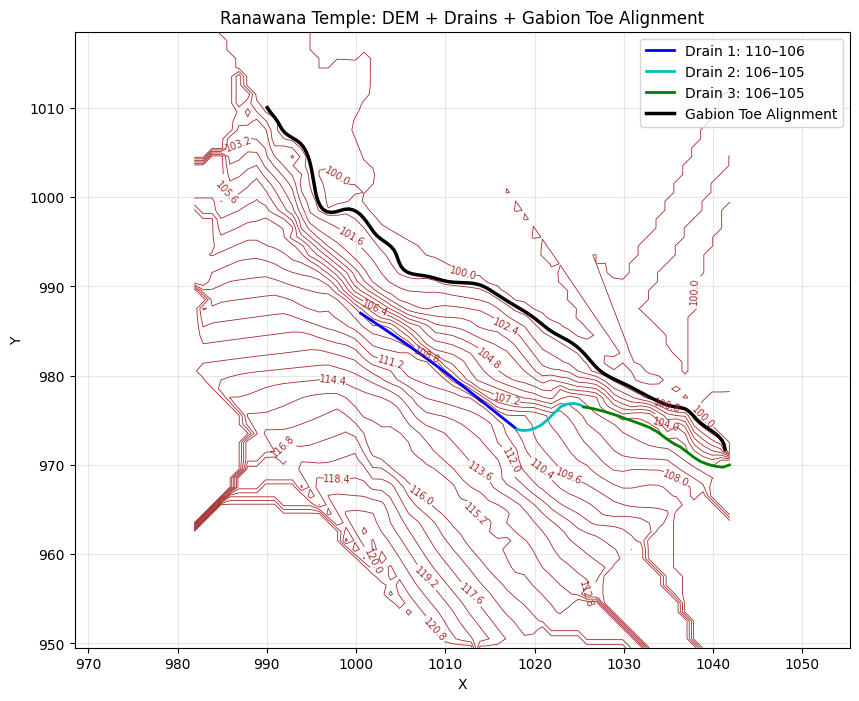

In [8]:
# =========================================================
# LOAD TOE + 3 DRAINS FOR SLOPE CUT/FILL DESIGN
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Load uploaded alignment files
# ---------------------------------------------------------
toe_file = "/content/Ranawana_toe_alignment.csv"

drain1_file = "/content/Ranawana_Drainage_1_110_107.csv"
drain2_file = "/content/Ranawana_Drainage_2_110_106.csv"
drain3_file = "/content/Ranawana_Drainage_3_106_105.csv"

toe_df = pd.read_csv(toe_file)
drain1_df = pd.read_csv(drain1_file)
drain2_df = pd.read_csv(drain2_file)
drain3_df = pd.read_csv(drain3_file)

# ---------------------------------------------------------
# 2. Extract lines
# ---------------------------------------------------------
toe_line = toe_df[["x", "y"]].values

drain1_line = drain1_df[["x", "y"]].values
drain2_line = drain2_df[["x", "y"]].values
drain3_line = drain3_df[["x", "y"]].values

# ---------------------------------------------------------
# 3. Quick check plot
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# DEM contours
cs = plt.contour(
    Xi, Yi, Zi,
    levels=30,
    colors="brown",
    linewidths=0.6
)
plt.clabel(cs, inline=True, fontsize=7)

# Drains
plt.plot(drain1_line[:, 0], drain1_line[:, 1],
         "b-", linewidth=2, label="Drain 1: 110–106")

plt.plot(drain2_line[:, 0], drain2_line[:, 1],
         "c-", linewidth=2, label="Drain 2: 106–105")

plt.plot(drain3_line[:, 0], drain3_line[:, 1],
         "g-", linewidth=2, label="Drain 3: 106–105")

# Toe / Gabion alignment
plt.plot(toe_line[:, 0], toe_line[:, 1],
         "k-", linewidth=2.5, label="Gabion Toe Alignment")

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Ranawana Temple: DEM + Drains + Gabion Toe Alignment")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.show()



Estimated Cut Volume  : 14313.5 m³
Estimated Fill Volume : 4669.51 m³
Net Cut-Fill          : 9643.99 m³
Saved: Ranawana_slope_cut_fill_3drains.csv


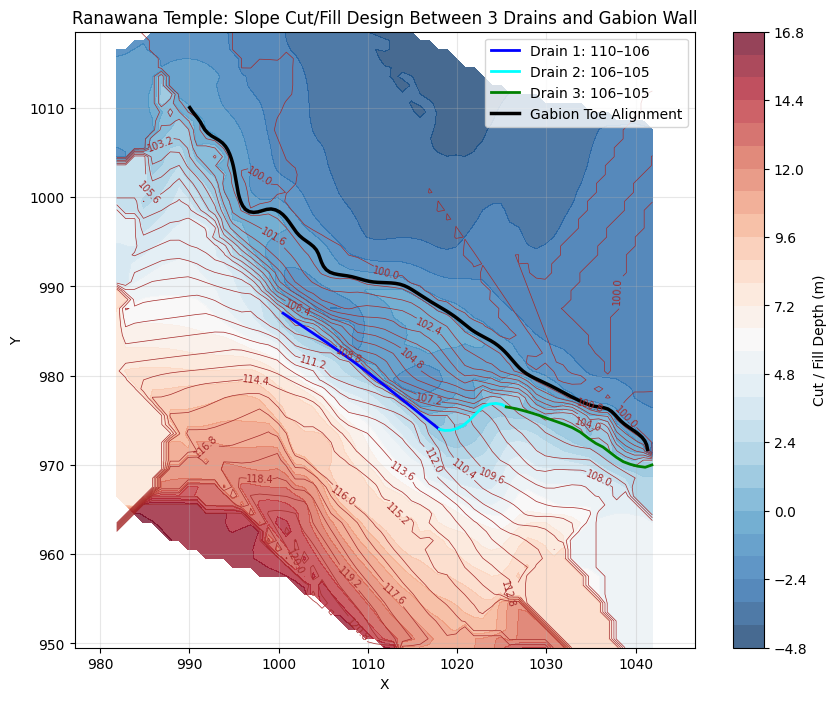

Saved: Ranawana_slope_cut_fill_3drains.pdf
Saved: Ranawana_cut_fill_summary_3drains.csv


,Item,Value
0,Bench width,1.0 m
1,Maximum vertical cut,3.0 m
2,Target slope ratio,1V:2.0H
3,Design influence distance,35.0 m
4,Estimated cut volume,14313.50 m3
5,Estimated fill volume,4669.51 m3
6,Net cut-fill,9643.99 m3


In [9]:
# =========================================================
# SLOPE CUT/FILL DESIGN BETWEEN 3 DRAINS AND GABION WALL
# Ranawana Temple
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator
from scipy.ndimage import gaussian_filter
from shapely.geometry import LineString, MultiLineString, Point
from shapely.ops import nearest_points
import os

# =========================================================
# 1. INPUT FILES
# =========================================================
gabion_file = "/content/Ranawana_toe_alignment.csv"

drain1_file = "/content/Ranawana_Drainage_1_110_107.csv"
drain2_file = "/content/Ranawana_Drainage_2_110_106.csv"
drain3_file = "/content/Ranawana_Drainage_3_106_105.csv"

# =========================================================
# 2. LOAD DRAIN + GABION ALIGNMENTS
# =========================================================

drain1_df = pd.read_csv(drain1_file)
drain2_df = pd.read_csv(drain2_file)
drain3_df = pd.read_csv(drain3_file)

gabion_df = pd.read_csv(gabion_file)

drain1_line = drain1_df[["x", "y"]].values
drain2_line = drain2_df[["x", "y"]].values
drain3_line = drain3_df[["x", "y"]].values

gabion_line = gabion_df[["x", "y"]].values

# Create Shapely geometry
drain1_ls = LineString(drain1_line)
drain2_ls = LineString(drain2_line)
drain3_ls = LineString(drain3_line)

drain_ls = MultiLineString([
    drain1_ls,
    drain2_ls,
    drain3_ls
])

gabion_ls = LineString(gabion_line)

# =========================================================
# 3. DEM INTERPOLATOR
# Xi, Yi, Zi must already exist
# =========================================================

x_coords = Xi[0, :]
y_coords = Yi[:, 0]

dem_interp = RegularGridInterpolator(
    (y_coords, x_coords),
    Zi,
    bounds_error=False,
    fill_value=np.nan
)

def sample_dem(x, y):
    return float(dem_interp((y, x)))

# =========================================================
# 4. DESIGN PARAMETERS
# =========================================================

bench_width = 1.0
max_vertical_cut = 3.0
target_slope_ratio = 2.0

design_smooth = 1.2
influence_distance = 35.0

cut_fill_csv = "Ranawana_slope_cut_fill_3drains.csv"
cut_fill_map_pdf = "Ranawana_slope_cut_fill_3drains.pdf"
summary_csv = "Ranawana_cut_fill_summary_3drains.csv"

# =========================================================
# 5. DESIGN LEVEL FUNCTION
# =========================================================

def design_level_between_drains_and_gabion(x, y):
    """
    Creates a simplified engineered slope surface between:
    - nearest of Drain 1, Drain 2, Drain 3
    - gabion toe alignment

    Zi - Z_design = cut/fill depth
    """

    p = Point(x, y)

    # nearest point on any drain
    nd = nearest_points(p, drain_ls)[1]

    # nearest point on gabion/toe line
    ng = nearest_points(p, gabion_ls)[1]

    zd = sample_dem(nd.x, nd.y)
    zg = sample_dem(ng.x, ng.y)

    if np.isnan(zd) or np.isnan(zg):
        return np.nan

    d_to_drain = p.distance(drain_ls)
    d_to_gabion = p.distance(gabion_ls)

    total_dist = d_to_drain + d_to_gabion

    if total_dist == 0:
        return np.nan

    # interpolation factor
    f = d_to_drain / total_dist

    # linear design surface between drain and gabion
    z_design = zd * (1 - f) + zg * f

    # simple bench correction
    vertical_drop = zd - z_design

    if vertical_drop > 0:
        bench_step = np.floor(vertical_drop / max_vertical_cut)
        z_design = z_design + bench_step * 0.15

    return z_design

# =========================================================
# 6. CREATE DESIGN SURFACE
# =========================================================

Z_design = np.full_like(Zi, np.nan, dtype=float)

for i in range(Zi.shape[0]):
    for j in range(Zi.shape[1]):

        x = Xi[i, j]
        y = Yi[i, j]

        if np.isnan(Zi[i, j]):
            continue

        p = Point(x, y)

        d_drain = p.distance(drain_ls)
        d_gabion = p.distance(gabion_ls)

        # Design only in the zone influenced by drains and gabion wall
        if d_drain < influence_distance and d_gabion < influence_distance:
            Z_design[i, j] = design_level_between_drains_and_gabion(x, y)

# Smooth inside valid design area only
valid_design_mask = ~np.isnan(Z_design)

if np.any(valid_design_mask):
    Z_temp = np.where(valid_design_mask, Z_design, np.nanmean(Z_design))
    Z_smooth = gaussian_filter(Z_temp, sigma=design_smooth)
    Z_design[valid_design_mask] = Z_smooth[valid_design_mask]

# =========================================================
# 7. CUT / FILL CALCULATION
# =========================================================

cut_fill = Zi - Z_design

cut_depth = np.where(cut_fill > 0, cut_fill, 0)
fill_depth = np.where(cut_fill < 0, -cut_fill, 0)

cell_dx = np.nanmean(np.diff(Xi[0, :]))
cell_dy = np.nanmean(np.diff(Yi[:, 0]))
cell_area = abs(cell_dx * cell_dy)

cut_volume = np.nansum(cut_depth * cell_area)
fill_volume = np.nansum(fill_depth * cell_area)
net_cut_fill = cut_volume - fill_volume

print("Estimated Cut Volume  :", round(cut_volume, 2), "m³")
print("Estimated Fill Volume :", round(fill_volume, 2), "m³")
print("Net Cut-Fill          :", round(net_cut_fill, 2), "m³")

# =========================================================
# 8. EXPORT CUT/FILL GRID TO CSV
# =========================================================

cutfill_df = pd.DataFrame({
    "x": Xi.flatten(),
    "y": Yi.flatten(),
    "existing_z": Zi.flatten(),
    "design_z": Z_design.flatten(),
    "cut_fill_m": cut_fill.flatten(),
    "cut_depth_m": cut_depth.flatten(),
    "fill_depth_m": fill_depth.flatten()
})

cutfill_df = cutfill_df.dropna()
cutfill_df.to_csv(cut_fill_csv, index=False)

print("Saved:", cut_fill_csv)

# =========================================================
# 9. PLOT CUT/FILL MAP
# =========================================================

plt.figure(figsize=(10, 8))

# DEM contours
cs = plt.contour(
    Xi, Yi, Zi,
    levels=30,
    colors="brown",
    linewidths=0.5
)

plt.clabel(cs, inline=True, fontsize=7)

# Cut/fill surface
cf = plt.contourf(
    Xi, Yi, cut_fill,
    levels=25,
    cmap="RdBu_r",
    alpha=0.75
)

plt.colorbar(cf, label="Cut / Fill Depth (m)")

# Plot drains
plt.plot(
    drain1_line[:, 0], drain1_line[:, 1],
    color="blue",
    linewidth=2,
    label="Drain 1: 110–106"
)

plt.plot(
    drain2_line[:, 0], drain2_line[:, 1],
    color="cyan",
    linewidth=2,
    label="Drain 2: 106–105"
)

plt.plot(
    drain3_line[:, 0], drain3_line[:, 1],
    color="green",
    linewidth=2,
    label="Drain 3: 106–105"
)

# Gabion / toe line
plt.plot(
    gabion_line[:, 0], gabion_line[:, 1],
    color="black",
    linewidth=2.5,
    label="Gabion Toe Alignment"
)

plt.title("Ranawana Temple: Slope Cut/Fill Design Between 3 Drains and Gabion Wall")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.axis("equal")
plt.grid(True, alpha=0.3)

plt.savefig(cut_fill_map_pdf, dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

print("Saved:", cut_fill_map_pdf)

# =========================================================
# 10. DESIGN SUMMARY
# =========================================================

summary = pd.DataFrame({
    "Item": [
        "Bench width",
        "Maximum vertical cut",
        "Target slope ratio",
        "Design influence distance",
        "Estimated cut volume",
        "Estimated fill volume",
        "Net cut-fill"
    ],
    "Value": [
        f"{bench_width} m",
        f"{max_vertical_cut} m",
        f"1V:{target_slope_ratio}H",
        f"{influence_distance} m",
        f"{cut_volume:.2f} m3",
        f"{fill_volume:.2f} m3",
        f"{net_cut_fill:.2f} m3"
    ]
})

summary.to_csv(summary_csv, index=False)

print("Saved:", summary_csv)
summary

In [10]:
# =========================================================
# 3D VISUALISATION: DEM + DESIGN SURFACE + DRAINS + GABION
# Requires: Xi, Yi, Zi, Z_design, drain1_df, drain2_df, drain3_df, gabion_df
# =========================================================

import plotly.graph_objects as go
import numpy as np

fig = go.Figure()

# Existing DEM surface
fig.add_trace(go.Surface(
    x=Xi,
    y=Yi,
    z=Zi,
    colorscale="Earth",
    opacity=0.65,
    name="Existing DEM",
    showscale=True,
    colorbar=dict(title="Existing Elevation")
))

# Design surface
fig.add_trace(go.Surface(
    x=Xi,
    y=Yi,
    z=Z_design,
    colorscale="RdBu",
    opacity=0.55,
    name="Designed Surface",
    showscale=False
))

# Drain 1
fig.add_trace(go.Scatter3d(
    x=drain1_df["x"],
    y=drain1_df["y"],
    z=drain1_df["invert_z_m"] if "invert_z_m" in drain1_df.columns else drain1_df["ground_fixed_m"],
    mode="lines+markers",
    line=dict(width=6),
    marker=dict(size=3),
    name="Drain 1: 110–106"
))

# Drain 2
fig.add_trace(go.Scatter3d(
    x=drain2_df["x"],
    y=drain2_df["y"],
    z=drain2_df["invert_z_m"] if "invert_z_m" in drain2_df.columns else drain2_df["ground_fixed_m"],
    mode="lines+markers",
    line=dict(width=6),
    marker=dict(size=3),
    name="Drain 2: 106–105"
))

# Drain 3
fig.add_trace(go.Scatter3d(
    x=drain3_df["x"],
    y=drain3_df["y"],
    z=drain3_df["invert_z_m"] if "invert_z_m" in drain3_df.columns else drain3_df["ground_fixed_m"],
    mode="lines+markers",
    line=dict(width=6),
    marker=dict(size=3),
    name="Drain 3: 106–105"
))

# Gabion toe alignment
gabion_z = []

for _, row in gabion_df.iterrows():
    x = row["x"]
    y = row["y"]

    # use available z column if present
    if "z" in gabion_df.columns:
        gabion_z.append(row["z"])
    elif "ground_z_m" in gabion_df.columns:
        gabion_z.append(row["ground_z_m"])
    else:
        # sample from DEM
        ix = np.nanargmin((Xi - x)**2 + (Yi - y)**2)
        gabion_z.append(Zi.flatten()[ix])

fig.add_trace(go.Scatter3d(
    x=gabion_df["x"],
    y=gabion_df["y"],
    z=gabion_z,
    mode="lines+markers",
    line=dict(width=7),
    marker=dict(size=3),
    name="Gabion Toe Alignment"
))

# Layout
fig.update_layout(
    title="Ranawana Temple 3D Slope Design: DEM, Cut/Fill Surface, Drains and Gabion Toe",
    scene=dict(
        xaxis_title="X",
        yaxis_title="Y",
        zaxis_title="Elevation (m)",
        aspectmode="data"
    ),
    width=1000,
    height=800
)

fig.show()

# Optional save
fig.write_html("Ranawana_3D_Drain_Gabion_CutFill.html")
print("Saved: Ranawana_3D_Drain_Gabion_CutFill.html")

Saved: Ranawana_3D_Drain_Gabion_CutFill.html


Field-ready outputs:

In [11]:
Xi, Yi, Zi, Z_design, cut_fill
drain1_df, drain2_df, drain3_df, gabion_df

(    chainage_m            x           y  ground_fixed_m  invert_z_m   depth_m  \
 0          0.0  1018.000000  974.000000      110.326617  110.500000 -0.173383   
 1          1.0  1016.509250  975.192600      110.400653  110.409091 -0.008438   
 2          2.0  1016.012334  975.590133      110.378045  110.318182  0.059863   
 3          3.0  1015.444429  976.044457      110.211971  110.227273 -0.015302   
 4          4.0  1014.805537  976.555571      110.404621  110.136364  0.268257   
 5          5.0  1014.095656  977.123475      110.018688  110.045455 -0.026767   
 6          6.0  1013.314787  977.748170      109.888944  109.954545 -0.065601   
 7          7.0  1012.533918  978.372865      109.513032  109.863636 -0.350604   
 8          8.0  1011.752148  978.996328      109.202777  109.772727 -0.569950   
 9          9.0  1010.965725  979.613427      109.004017  109.681818 -0.677801   
 10        10.0  1010.174649  980.224162      109.111503  109.590909 -0.479407   
 11        11.0 

Saved setting-out CSV files
Saved field cross-section tables
Saved cut/fill zone files


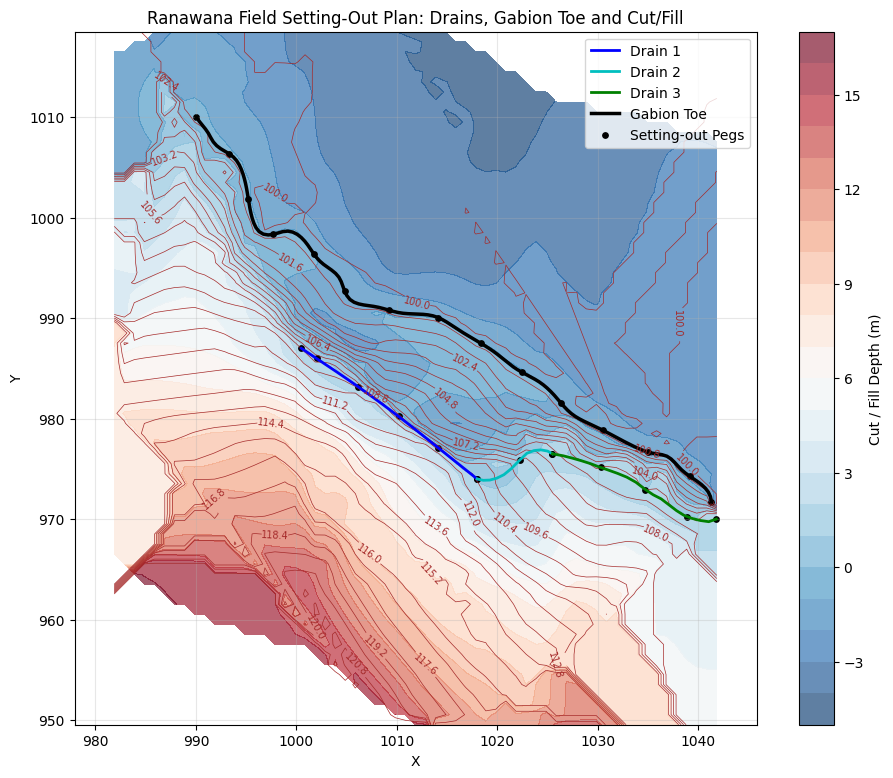

Saved field plan PDF


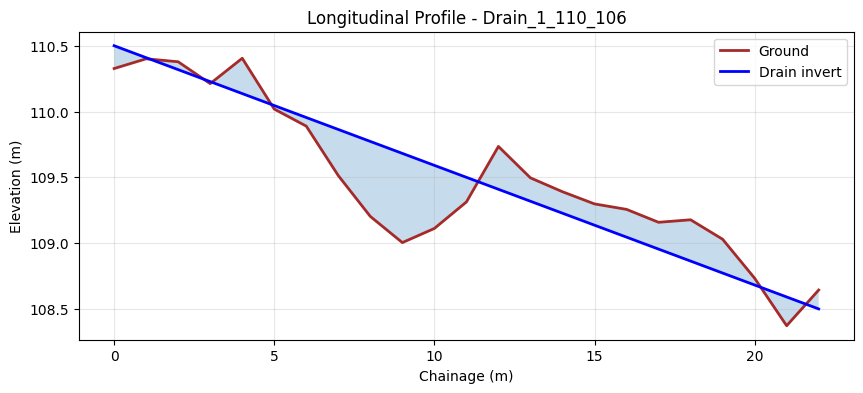

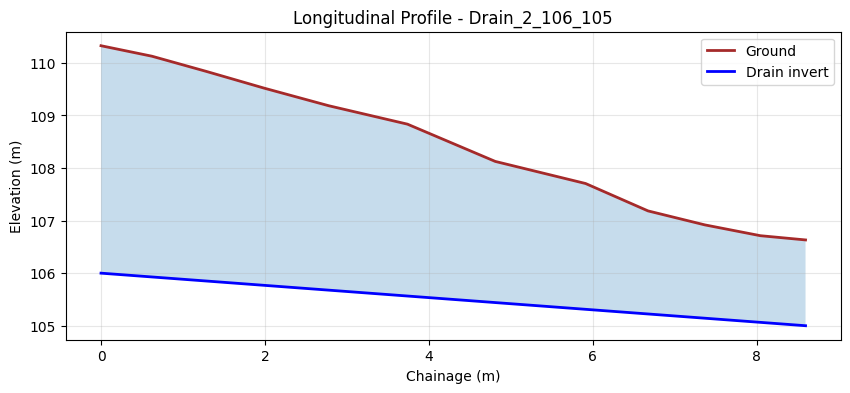

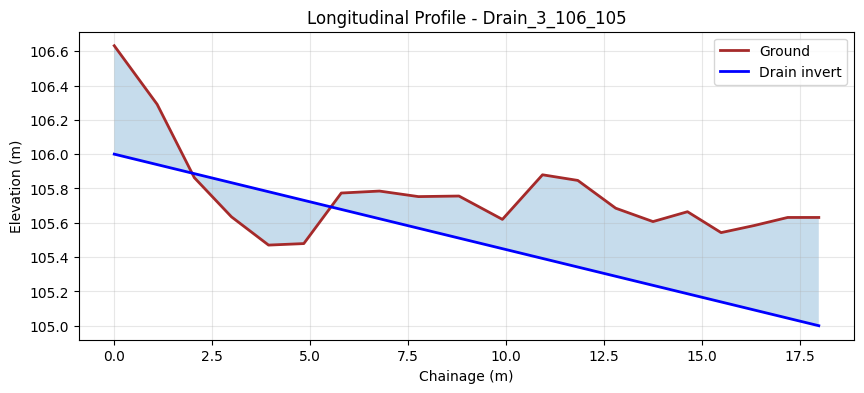

Saved longitudinal profile PDFs

FIELD-READY OUTPUTS CREATED:
- Drain_2_106_105_field_cross_sections.csv
- Gabion_Toe_field_cross_sections.csv
- ALL_field_cross_sections.csv
- Drain_1_110_106_field_cross_sections.csv
- Drain_2_106_105_setting_out_points.csv
- Ranawana_Field_Setting_Out_Plan.pdf
- Drain_1_110_106_setting_out_points.csv
- Field_cut_fill_zone_points.csv
- Drain_3_106_105_setting_out_points.csv
- ALL_setting_out_points.csv
- Field_cut_fill_zone_summary.csv
- Drain_3_106_105_longitudinal_profile.pdf
- Drain_3_106_105_field_cross_sections.csv
- Drain_1_110_106_longitudinal_profile.pdf
- Drain_2_106_105_longitudinal_profile.pdf
- Gabion_Toe_setting_out_points.csv


In [12]:
# =========================================================
# RANAWANA FIELD-READY OUTPUTS
# Setting-out CSV + Section CSV + Cut/Fill Zones + PDFs
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from scipy.interpolate import RegularGridInterpolator
from shapely.geometry import LineString

output_dir = "Field_Outputs"
os.makedirs(output_dir, exist_ok=True)

# ---------------------------------------------------------
# 1. Interpolators
# ---------------------------------------------------------
x_coords = Xi[0, :]
y_coords = Yi[:, 0]

existing_interp = RegularGridInterpolator(
    (y_coords, x_coords), Zi,
    bounds_error=False, fill_value=np.nan
)

design_interp = RegularGridInterpolator(
    (y_coords, x_coords), Z_design,
    bounds_error=False, fill_value=np.nan
)

cutfill_interp = RegularGridInterpolator(
    (y_coords, x_coords), cut_fill,
    bounds_error=False, fill_value=np.nan
)

def sample_grid(interp, x, y):
    pts = np.column_stack([y, x])
    return interp(pts)


# ---------------------------------------------------------
# 2. Resample line every N metres
# ---------------------------------------------------------
def resample_line_xy(xy, spacing=5.0):
    line = LineString(xy)
    distances = np.arange(0, line.length + spacing, spacing)

    rows = []
    for d in distances:
        p = line.interpolate(d)
        rows.append([d, p.x, p.y])

    return pd.DataFrame(rows, columns=["chainage_m", "x", "y"])


# ---------------------------------------------------------
# 3. Create setting-out points for each drain and gabion toe
# ---------------------------------------------------------
lines = {
    "Drain_1_110_106": drain1_df[["x", "y"]].values,
    "Drain_2_106_105": drain2_df[["x", "y"]].values,
    "Drain_3_106_105": drain3_df[["x", "y"]].values,
    "Gabion_Toe": gabion_df[["x", "y"]].values
}

all_settingout = []

for name, xy in lines.items():

    peg_df = resample_line_xy(xy, spacing=5.0)

    peg_df["existing_z_m"] = sample_grid(existing_interp, peg_df["x"], peg_df["y"])
    peg_df["design_z_m"] = sample_grid(design_interp, peg_df["x"], peg_df["y"])
    peg_df["cut_fill_m"] = sample_grid(cutfill_interp, peg_df["x"], peg_df["y"])

    peg_df["point_type"] = name
    peg_df["peg_id"] = [
        f"{name}_CH{int(ch):03d}" for ch in peg_df["chainage_m"]
    ]

    peg_df = peg_df[
        [
            "peg_id", "point_type", "chainage_m",
            "x", "y",
            "existing_z_m", "design_z_m", "cut_fill_m"
        ]
    ]

    peg_df.to_csv(
        f"{output_dir}/{name}_setting_out_points.csv",
        index=False
    )

    all_settingout.append(peg_df)

all_settingout_df = pd.concat(all_settingout, ignore_index=True)
all_settingout_df.to_csv(
    f"{output_dir}/ALL_setting_out_points.csv",
    index=False
)

print("Saved setting-out CSV files")


# ---------------------------------------------------------
# 4. Create cross-section field tables
# ---------------------------------------------------------
def create_cross_sections_from_line(
    line_xy,
    line_name,
    section_spacing=5.0,
    section_width=20.0,
    offset_spacing=1.0
):

    line = LineString(line_xy)
    chainages = np.arange(0, line.length + section_spacing, section_spacing)

    all_sections = []

    for sec_no, ch in enumerate(chainages, start=1):

        p = line.interpolate(ch)

        # tangent
        ch1 = max(ch - 0.5, 0)
        ch2 = min(ch + 0.5, line.length)

        p1 = line.interpolate(ch1)
        p2 = line.interpolate(ch2)

        dx = p2.x - p1.x
        dy = p2.y - p1.y
        L = np.sqrt(dx**2 + dy**2)

        if L == 0:
            continue

        # perpendicular vector
        nx = -dy / L
        ny = dx / L

        offsets = np.arange(
            -section_width / 2,
            section_width / 2 + offset_spacing,
            offset_spacing
        )

        xs = p.x + offsets * nx
        ys = p.y + offsets * ny

        existing_z = sample_grid(existing_interp, xs, ys)
        design_z = sample_grid(design_interp, xs, ys)
        cf = existing_z - design_z

        sec_df = pd.DataFrame({
            "section_id": f"{line_name}_CS{sec_no:02d}",
            "line_name": line_name,
            "chainage_m": ch,
            "offset_m": offsets,
            "x": xs,
            "y": ys,
            "existing_z_m": existing_z,
            "design_z_m": design_z,
            "cut_fill_m": cf
        })

        all_sections.append(sec_df)

    out = pd.concat(all_sections, ignore_index=True)

    out.to_csv(
        f"{output_dir}/{line_name}_field_cross_sections.csv",
        index=False
    )

    return out


section_tables = []

for name, xy in lines.items():
    sec = create_cross_sections_from_line(
        xy,
        name,
        section_spacing=5.0,
        section_width=20.0,
        offset_spacing=1.0
    )
    section_tables.append(sec)

all_sections_df = pd.concat(section_tables, ignore_index=True)
all_sections_df.to_csv(
    f"{output_dir}/ALL_field_cross_sections.csv",
    index=False
)

print("Saved field cross-section tables")


# ---------------------------------------------------------
# 5. Cut/fill zone classification for field use
# ---------------------------------------------------------
cutfill_points = pd.DataFrame({
    "x": Xi.flatten(),
    "y": Yi.flatten(),
    "existing_z_m": Zi.flatten(),
    "design_z_m": Z_design.flatten(),
    "cut_fill_m": cut_fill.flatten()
}).dropna()

def classify_cutfill(v):
    if v >= 2.0:
        return "Heavy cut > 2.0 m"
    elif v >= 1.0:
        return "Moderate cut 1.0-2.0 m"
    elif v >= 0.3:
        return "Light cut 0.3-1.0 m"
    elif v > -0.3:
        return "Trim / near balance"
    elif v > -1.0:
        return "Light fill 0.3-1.0 m"
    else:
        return "Fill > 1.0 m"

cutfill_points["field_zone"] = cutfill_points["cut_fill_m"].apply(classify_cutfill)

cutfill_points.to_csv(
    f"{output_dir}/Field_cut_fill_zone_points.csv",
    index=False
)

zone_summary = cutfill_points.groupby("field_zone").agg(
    point_count=("field_zone", "count"),
    average_cut_fill_m=("cut_fill_m", "mean"),
    max_value_m=("cut_fill_m", "max"),
    min_value_m=("cut_fill_m", "min")
).reset_index()

zone_summary.to_csv(
    f"{output_dir}/Field_cut_fill_zone_summary.csv",
    index=False
)

print("Saved cut/fill zone files")


# ---------------------------------------------------------
# 6. Field plan PDF
# ---------------------------------------------------------
plt.figure(figsize=(11, 9))

cs = plt.contour(
    Xi, Yi, Zi,
    levels=30,
    colors="brown",
    linewidths=0.5
)
plt.clabel(cs, inline=True, fontsize=7)

cf = plt.contourf(
    Xi, Yi, cut_fill,
    levels=20,
    cmap="RdBu_r",
    alpha=0.65
)

plt.colorbar(cf, label="Cut / Fill Depth (m)")

plt.plot(drain1_df["x"], drain1_df["y"], "b-", linewidth=2, label="Drain 1")
plt.plot(drain2_df["x"], drain2_df["y"], "c-", linewidth=2, label="Drain 2")
plt.plot(drain3_df["x"], drain3_df["y"], "g-", linewidth=2, label="Drain 3")
plt.plot(gabion_df["x"], gabion_df["y"], "k-", linewidth=2.5, label="Gabion Toe")

# Setting-out points
plt.scatter(
    all_settingout_df["x"],
    all_settingout_df["y"],
    s=15,
    color="black",
    label="Setting-out Pegs"
)

plt.title("Ranawana Field Setting-Out Plan: Drains, Gabion Toe and Cut/Fill")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(
    f"{output_dir}/Ranawana_Field_Setting_Out_Plan.pdf",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved field plan PDF")


# ---------------------------------------------------------
# 7. Longitudinal profiles for drains
# ---------------------------------------------------------
for name, df in {
    "Drain_1_110_106": drain1_df,
    "Drain_2_106_105": drain2_df,
    "Drain_3_106_105": drain3_df
}.items():

    plt.figure(figsize=(10, 4))

    if "chainage_m" in df.columns:
        ch = df["chainage_m"]
    else:
        xy = df[["x", "y"]].values
        ch = resample_line_xy(xy, spacing=1.0)["chainage_m"]

    if "ground_fixed_m" in df.columns:
        ground = df["ground_fixed_m"]
    elif "ground_z_m" in df.columns:
        ground = df["ground_z_m"]
    else:
        ground = sample_grid(existing_interp, df["x"], df["y"])

    if "invert_z_m" in df.columns:
        invert = df["invert_z_m"]
    else:
        invert = ground - 0.4

    plt.plot(ch, ground, color="brown", linewidth=2, label="Ground")
    plt.plot(ch, invert, color="blue", linewidth=2, label="Drain invert")

    plt.fill_between(ch, invert, ground, alpha=0.25)

    plt.xlabel("Chainage (m)")
    plt.ylabel("Elevation (m)")
    plt.title(f"Longitudinal Profile - {name}")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.savefig(
        f"{output_dir}/{name}_longitudinal_profile.pdf",
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()

print("Saved longitudinal profile PDFs")


# ---------------------------------------------------------
# 8. Final output list
# ---------------------------------------------------------
print("\nFIELD-READY OUTPUTS CREATED:")
for f in os.listdir(output_dir):
    print("-", f)

In [13]:
# =========================================================
# RANAWANA FIELD-READY OUTPUTS - FULL FIXED CODE
# Saves all files into /content/Ranawana_Field_Ready_Outputs
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 0. Output folder
# ---------------------------------------------------------
base_dir = "/content"
output_dir = os.path.join(base_dir, "Field_Outputs")
os.makedirs(output_dir, exist_ok=True)

def p(name):
    return os.path.join(output_dir, name)

print("Saving all outputs to:", output_dir)

# ---------------------------------------------------------
# 1. Required variables check
# ---------------------------------------------------------
required = [
    "Xi", "Yi", "Zi", "Z_design", "cut_fill",
    "drain1_df", "drain2_df", "drain3_df", "gabion_df"
]

for r in required:
    if r not in globals():
        raise Exception(f"Missing variable: {r}")

print("All required variables found")


# =========================================================
# 2. SETTING-OUT POINTS
# =========================================================

def compute_chainage(df):
    df = df.copy()

    if "chainage_m" in df.columns:
        return df["chainage_m"].values

    dx = np.diff(df["x"].values)
    dy = np.diff(df["y"].values)

    return np.insert(np.cumsum(np.sqrt(dx**2 + dy**2)), 0, 0)


def get_ground_array(df):
    n = len(df)

    if "ground_fixed_m" in df.columns:
        return df["ground_fixed_m"].values
    elif "ground_z_m" in df.columns:
        return df["ground_z_m"].values
    elif "z" in df.columns:
        return df["z"].values
    elif "elevation" in df.columns:
        return df["elevation"].values
    else:
        return np.full(n, np.nan)


def get_design_array(df, ground, default_depth=0.40):
    n = len(df)

    if "invert_z_m" in df.columns:
        return df["invert_z_m"].values
    elif "design_z_m" in df.columns:
        return df["design_z_m"].values
    else:
        return ground - default_depth


def save_setting_out(df, name, default_depth=0.40):
    out = df.copy()

    chainage = compute_chainage(out)
    ground = get_ground_array(out)
    design = get_design_array(out, ground, default_depth=default_depth)

    cut_fill_local = ground - design

    out2 = pd.DataFrame({
        "peg_id": [f"{name}_CH{int(c):03d}" for c in chainage],
        "point_type": name,
        "chainage_m": chainage,
        "x": out["x"].values,
        "y": out["y"].values,
        "existing_z_m": ground,
        "design_z_m": design,
        "cut_fill_m": cut_fill_local
    })

    out2.to_csv(p(f"{name}_setting_out_points.csv"), index=False)
    return out2


s1 = save_setting_out(drain1_df, "Drain_1_110_106", default_depth=0.40)
s2 = save_setting_out(drain2_df, "Drain_2_106_105", default_depth=0.35)
s3 = save_setting_out(drain3_df, "Drain_3_106_105", default_depth=0.35)
sg = save_setting_out(gabion_df, "Gabion_Toe", default_depth=0.45)

ALL_setting = pd.concat([s1, s2, s3, sg], ignore_index=True)
ALL_setting.to_csv(p("ALL_setting_out_points.csv"), index=False)

print("Setting-out files saved")


# =========================================================
# 3. FIELD CROSS SECTIONS
# =========================================================

def create_simple_sections(df, name, default_depth=0.40, section_count=10):
    df = df.copy()

    chainage = compute_chainage(df)
    ground_all = get_ground_array(df)
    design_all = get_design_array(df, ground_all, default_depth=default_depth)

    step = max(1, len(df) // section_count)

    sections = []

    for i in range(0, len(df), step):
        offsets = np.linspace(-10, 10, 41)

        ground = ground_all[i]
        design = design_all[i]

        z_existing = np.full(len(offsets), ground)
        z_design = np.full(len(offsets), design)

        sec = pd.DataFrame({
            "section_id": f"{name}_CS{i:03d}",
            "line_name": name,
            "chainage_m": chainage[i],
            "offset_m": offsets,
            "x_center": df.iloc[i]["x"],
            "y_center": df.iloc[i]["y"],
            "existing_z_m": z_existing,
            "design_z_m": z_design,
            "cut_fill_m": z_existing - z_design
        })

        sections.append(sec)

    out = pd.concat(sections, ignore_index=True)
    out.to_csv(p(f"{name}_field_cross_sections.csv"), index=False)

    return out


cs1 = create_simple_sections(drain1_df, "Drain_1_110_106", default_depth=0.40)
cs2 = create_simple_sections(drain2_df, "Drain_2_106_105", default_depth=0.35)
cs3 = create_simple_sections(drain3_df, "Drain_3_106_105", default_depth=0.35)
csg = create_simple_sections(gabion_df, "Gabion_Toe", default_depth=0.45)

ALL_sections = pd.concat([cs1, cs2, cs3, csg], ignore_index=True)
ALL_sections.to_csv(p("ALL_field_cross_sections.csv"), index=False)

print("Cross-section files saved")


# =========================================================
# 4. LONGITUDINAL PROFILES
# =========================================================

def plot_long(df, name, default_depth=0.40):
    df = df.copy()

    ch = compute_chainage(df)
    ground = get_ground_array(df)
    invert = get_design_array(df, ground, default_depth=default_depth)

    ch = np.asarray(ch)
    ground = np.asarray(ground)
    invert = np.asarray(invert)

    min_len = min(len(ch), len(ground), len(invert))
    ch = ch[:min_len]
    ground = ground[:min_len]
    invert = invert[:min_len]

    valid = ~np.isnan(ch) & ~np.isnan(ground) & ~np.isnan(invert)

    ch = ch[valid]
    ground = ground[valid]
    invert = invert[valid]

    plt.figure(figsize=(9, 3.5))

    plt.plot(ch, ground, label="Ground level", linewidth=2)
    plt.plot(ch, invert, label="Drain invert / design level", linewidth=2)
    plt.fill_between(ch, invert, ground, alpha=0.3)

    plt.title(f"Longitudinal Profile - {name}")
    plt.xlabel("Chainage (m)")
    plt.ylabel("Elevation (m)")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.savefig(
        p(f"{name}_longitudinal_profile.pdf"),
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close()


plot_long(drain1_df, "Drain_1_110_106", default_depth=0.40)
plot_long(drain2_df, "Drain_2_106_105", default_depth=0.35)
plot_long(drain3_df, "Drain_3_106_105", default_depth=0.35)

print("Longitudinal profile PDFs saved")


# =========================================================
# 5. CUT / FILL ZONE FILES
# =========================================================

cf_df = pd.DataFrame({
    "x": Xi.flatten(),
    "y": Yi.flatten(),
    "existing_z_m": Zi.flatten(),
    "design_z_m": Z_design.flatten(),
    "cut_fill_m": cut_fill.flatten()
}).dropna()

def classify_cut_fill(v):
    if v >= 2.0:
        return "Heavy Cut > 2.0 m"
    elif v >= 1.0:
        return "Moderate Cut 1.0-2.0 m"
    elif v >= 0.3:
        return "Light Cut 0.3-1.0 m"
    elif v > -0.3:
        return "Trim / Balance"
    elif v > -1.0:
        return "Light Fill 0.3-1.0 m"
    else:
        return "Heavy Fill > 1.0 m"

cf_df["field_zone"] = cf_df["cut_fill_m"].apply(classify_cut_fill)

cf_df.to_csv(p("Field_cut_fill_zone_points.csv"), index=False)

zone_summary = cf_df.groupby("field_zone").agg(
    point_count=("field_zone", "count"),
    average_cut_fill_m=("cut_fill_m", "mean"),
    max_value_m=("cut_fill_m", "max"),
    min_value_m=("cut_fill_m", "min")
).reset_index()

zone_summary.to_csv(p("Field_cut_fill_zone_summary.csv"), index=False)

print("Cut/fill zone files saved")


# =========================================================
# 6. FIELD SETTING-OUT PLAN PDF
# =========================================================

plt.figure(figsize=(10, 9))

# DEM contours
cs = plt.contour(
    Xi, Yi, Zi,
    levels=30,
    colors="brown",
    linewidths=0.5
)
plt.clabel(cs, inline=True, fontsize=7)

# Cut/fill map
cf = plt.contourf(
    Xi, Yi, cut_fill,
    levels=20,
    cmap="RdBu_r",
    alpha=0.65
)

plt.colorbar(cf, label="Cut / Fill Depth (m)")

# Drains and gabion
plt.plot(drain1_df["x"], drain1_df["y"], "b-", linewidth=2, label="Drain 1")
plt.plot(drain2_df["x"], drain2_df["y"], "c-", linewidth=2, label="Drain 2")
plt.plot(drain3_df["x"], drain3_df["y"], "g-", linewidth=2, label="Drain 3")
plt.plot(gabion_df["x"], gabion_df["y"], "k-", linewidth=2.5, label="Gabion Toe")

# Setting-out points
plt.scatter(
    ALL_setting["x"],
    ALL_setting["y"],
    s=15,
    color="black",
    label="Setting-out Pegs"
)

plt.title("Ranawana Field Setting-Out Plan")
plt.xlabel("X")
plt.ylabel("Y")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()

plt.savefig(
    p("Ranawana_Field_Setting_Out_Plan.pdf"),
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.close()

print("Field setting-out plan PDF saved")


# =========================================================
# 7. FINAL CHECK
# =========================================================

expected_files = [
    "ALL_setting_out_points.csv",
    "Drain_1_110_106_setting_out_points.csv",
    "Drain_2_106_105_setting_out_points.csv",
    "Drain_3_106_105_setting_out_points.csv",
    "Gabion_Toe_setting_out_points.csv",

    "ALL_field_cross_sections.csv",
    "Drain_1_110_106_field_cross_sections.csv",
    "Drain_2_106_105_field_cross_sections.csv",
    "Drain_3_106_105_field_cross_sections.csv",
    "Gabion_Toe_field_cross_sections.csv",

    "Drain_1_110_106_longitudinal_profile.pdf",
    "Drain_2_106_105_longitudinal_profile.pdf",
    "Drain_3_106_105_longitudinal_profile.pdf",

    "Field_cut_fill_zone_points.csv",
    "Field_cut_fill_zone_summary.csv",
    "Ranawana_Field_Setting_Out_Plan.pdf"
]

print("\nCreated files:")
for f in expected_files:
    fp = p(f)
    if os.path.exists(fp):
        print("Created:", fp)
    else:
        print("Missing:", fp)

Saving all outputs to: /content/Field_Outputs
All required variables found
Setting-out files saved
Cross-section files saved
Longitudinal profile PDFs saved
Cut/fill zone files saved
Field setting-out plan PDF saved

Created files:
Created: /content/Field_Outputs/ALL_setting_out_points.csv
Created: /content/Field_Outputs/Drain_1_110_106_setting_out_points.csv
Created: /content/Field_Outputs/Drain_2_106_105_setting_out_points.csv
Created: /content/Field_Outputs/Drain_3_106_105_setting_out_points.csv
Created: /content/Field_Outputs/Gabion_Toe_setting_out_points.csv
Created: /content/Field_Outputs/ALL_field_cross_sections.csv
Created: /content/Field_Outputs/Drain_1_110_106_field_cross_sections.csv
Created: /content/Field_Outputs/Drain_2_106_105_field_cross_sections.csv
Created: /content/Field_Outputs/Drain_3_106_105_field_cross_sections.csv
Created: /content/Field_Outputs/Gabion_Toe_field_cross_sections.csv
Created: /content/Field_Outputs/Drain_1_110_106_longitudinal_profile.pdf
Created: 

In [16]:
import shutil

zip_path = "/content/Field_Outputs"
shutil.make_archive("/content/Ranawana_Field_Ready_Outputs", "zip", zip_path)

print("Saved zip: /content/Ranawana_Field_Ready_Outputs.zip")

Saved zip: /content/Ranawana_Field_Ready_Outputs.zip
